<a href="https://colab.research.google.com/github/kayorde25/plant-seedling-classification-cnn/blob/main/Code_Plant_Seedling_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Model for Automated Plant Seedling Classification

## Problem
Manual identification of plant species in agriculture is time-consuming and requires expert knowledge. This creates inefficiencies in crop monitoring and weed management.

## Objective
The objective of this project is to build a Convolutional Neural Network (CNN) that can classify plant seedlings into 12 species using image data.

## Relevance
Automating plant seedling classification can reduce manual labour, improve efficiency in agricultural workflows, and support precision agriculture systems.

## Data Understanding

The dataset contains image data for 12 plant seedling species. The images are stored as NumPy arrays in `images.npy`, while the labels are stored in `Labels.csv`.

This is a multi-class image classification problem where the goal is to predict the correct plant species from image inputs.

Key considerations:
- The data consists of image arrays rather than standard tabular records
- Labels must be encoded for model training
- Image normalization is required before fitting the CNN

## Data Preprocessing

In this step, the image data is loaded, normalized, and reshaped as needed for input into the CNN model. The labels are also encoded into numeric form for multi-class classification.

## Importing necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Exploratory Analysis

Before model development, it is useful to examine the class distribution and inspect sample images. This helps assess class balance and understand the visual variation across species.

## Loading the dataset

In [ ]:
import os
import numpy as np
import pandas as pd

DATA_DIR = "data"

images_path = os.path.join(DATA_DIR, "images.npy")
labels_path = os.path.join(DATA_DIR, "Labels.csv")

# Check dataset exists
if not os.path.exists(images_path) or not os.path.exists(labels_path):
    raise FileNotFoundError(
        "Dataset not found.\n"
        "Download from: https://www.kaggle.com/datasets/abiolaoolaleye/computer-vision\n"
        "Place files in the 'data/' directory."
    )

# Load data
images = np.load(images_path)
labels_df = pd.read_csv(labels_path)

print("Images shape:", images.shape)
print("Labels shape:", labels_df.shape)

Images shape: (4750, 128, 128, 3)
Labels shape: (4750, 1)


Now we can download the dataset. The dataset is named `computer-vision` from user `abiolaoolaleye`.

In [ ]:
import os

# Define the directory where data should be stored
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# Download the dataset files into the DATA_DIR
!kaggle datasets download -d abiolaoolaleye/computer-vision -p {DATA_DIR} --unzip

print(f"Dataset downloaded and unzipped to '{DATA_DIR}/'.")

Dataset URL: https://www.kaggle.com/datasets/abiolaoolaleye/computer-vision
License(s): unknown
100% 178M/178M [00:01<00:00, 156MB/s]

Dataset downloaded and unzipped to 'data/'.


In [ ]:
# If using Google Colab
import os

if "COLAB_GPU" in os.environ:
    print("Running in Colab")

DATA_DIR = "data"

Running in Colab


##Inspect the datasets

In [ ]:
print(type(images))
print(type(labels_df))

print("Images shape:", images.shape)
print("Labels shape:", labels_df.shape)
print(labels_df.head())
print(labels_df.columns)

<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>
Images shape: (4750, 128, 128, 3)
Labels shape: (4750, 1)
                       Label
0  Small-flowered Cranesbill
1  Small-flowered Cranesbill
2  Small-flowered Cranesbill
3  Small-flowered Cranesbill
4  Small-flowered Cranesbill
Index(['Label'], dtype='object')


In [ ]:
print("Number of images:", len(images))
print("Number of labels:", len(labels_df))

assert len(images) == len(labels_df), "Mismatch: number of images and labels are not equal"

Number of images: 4750
Number of labels: 4750


In [ ]:
#Set the label
label_col = 'Label'

In [ ]:
#Inspect one image safely
print("First image shape:", images[0].shape)
print("First image dtype:", images[0].dtype)
print("Min pixel value:", images[0].min())
print("Max pixel value:", images[0].max())

First image shape: (128, 128, 3)
First image dtype: uint8
Min pixel value: 2
Max pixel value: 167


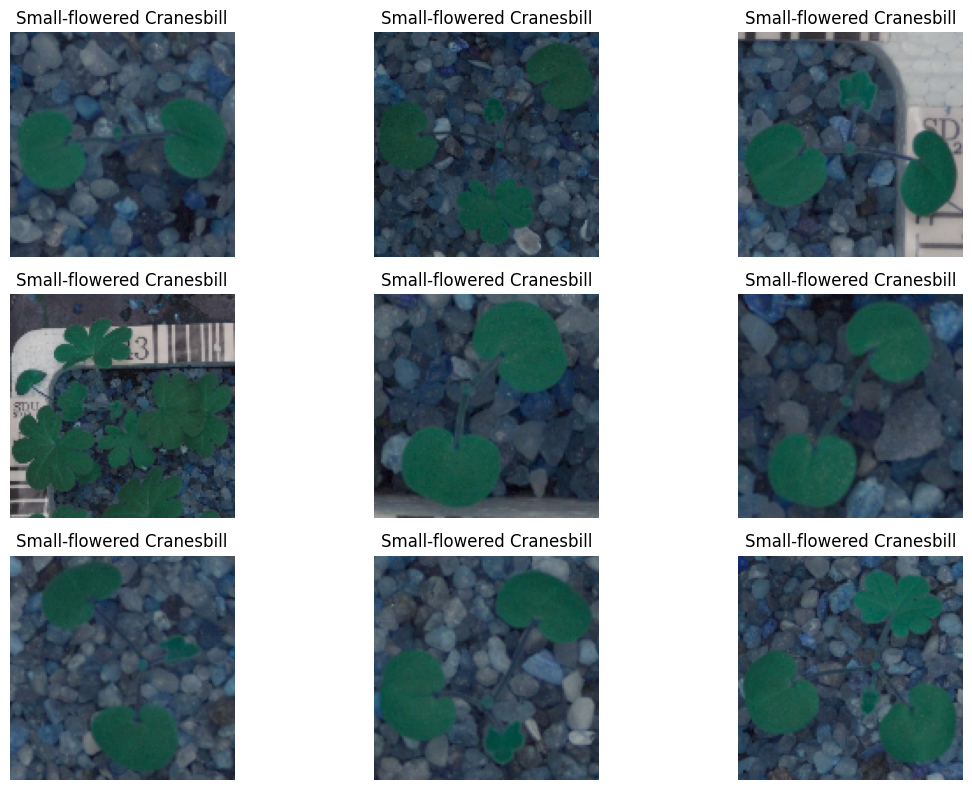

In [ ]:
#Show a few sample images
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].astype(np.uint8))
    plt.title(labels_df[label_col].iloc[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

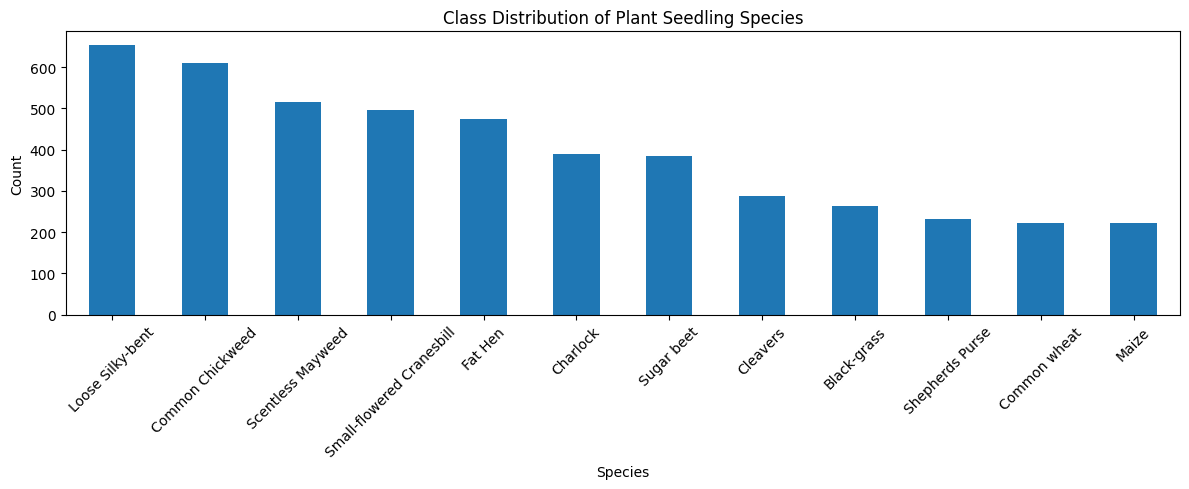

In [ ]:
# Plot class distribution
plt.figure(figsize=(12, 5))
labels_df[label_col].value_counts().plot(kind='bar')
plt.title("Class Distribution of Plant Seedling Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(labels_df[label_col])
y = to_categorical(y_encoded)

print("Classes:", le.classes_)
print("Encoded labels shape:", y.shape)

Classes: ['Black-grass' 'Charlock' 'Cleavers' 'Common Chickweed' 'Common wheat'
 'Fat Hen' 'Loose Silky-bent' 'Maize' 'Scentless Mayweed'
 'Shepherds Purse' 'Small-flowered Cranesbill' 'Sugar beet']
Encoded labels shape: (4750, 12)


In [ ]:
# Split the data
X_temp, X_test, y_temp, y_test, y_temp_enc, y_test_enc = train_test_split(
    X, y, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train, X_val, y_train, y_val, y_train_enc, y_val_enc = train_test_split(
    X_temp, y_temp, y_temp_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_temp_enc
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (3040, 128, 128, 3) (3040, 12)
Validation: (760, 128, 128, 3) (760, 12)
Test: (950, 128, 128, 3) (950, 12)


In [ ]:
# Normalize the images
X = images.astype('float32') / 255.0
print("X min:", X.min(), "X max:", X.max())

## CNN Model Development

A Convolutional Neural Network (CNN) is used because it is well suited to image classification tasks. CNNs automatically learn spatial features such as edges, shapes, and texture patterns that help distinguish between plant species.

The model architecture includes:
- Convolutional layers for feature extraction
- Pooling layers for dimensionality reduction
- Dense layers for classification
- Softmax activation for multi-class output

## Model Training

The CNN model is trained on the processed image data and evaluated on a validation set to monitor learning performance and generalization.

In [ ]:
IMG_SIZE = 128

# Build the CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=1
)

## Model Evaluation

The model is evaluated using classification accuracy and additional visual tools such as training curves, confusion matrix, and sample predictions. These help assess both predictive performance and error patterns across plant species.

In [ ]:
#Plot accuracy and loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate and predict
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

In [ ]:
#Classification report
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=le.classes_))

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Sample predictions
plt.figure(figsize=(15, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i])
    true_label = le.inverse_transform([y_true[i]])[0]
    pred_label = le.inverse_transform([y_pred[i]])[0]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Show only wrong predictions
wrong_idx = np.where(y_true != y_pred)[0]

plt.figure(figsize=(15, 10))

for i, idx in enumerate(wrong_idx[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[idx])
    true_label = le.inverse_transform([y_true[idx]])[0]
    pred_label = le.inverse_transform([y_pred[idx]])[0]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

##Improve the model with callbacks

In [ ]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# Add data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow(X_train, y_train, batch_size=32)


In [ ]:
# Improved CNN model
from tensorflow.keras.layers import BatchNormalization

final_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])

final_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

final_model.summary()

In [ ]:
#Train improved model
history_final = final_model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=15,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 28s 205ms/step - accuracy: 0.2773 - loss: 2.7123 - val_accuracy: 0.0605 - val_loss: 3.6769 - learning_rate: 0.0010
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step - accuracy: 0.4056 - loss: 1.8695 - val_accuracy: 0.0461 - val_loss: 7.1200 - learning_rate: 0.0010
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 16s 170ms/step - accuracy: 0.4836 - loss: 1.6100 - val_accuracy: 0.1382 - val_loss: 9.9819 - learning_rate: 0.0010
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.5437 - loss: 1.4244
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
95/95 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.5530 - loss: 1.4044 - val_accuracy: 0.1395 - val_loss: 7.4622 - learning_rate: 0.0010
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 17s 179ms/step - accuracy: 0.6020 - loss: 1.2325 - val_accuracy: 0.2145 - val_loss: 3.9411 - learning_rate: 5.0000e-04
Epoch 6/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.6447 - loss: 

In [ ]:
#Evaluate improved model
final_test_loss, final_test_acc = final_model.evaluate(X_test, y_test, verbose=1)
print("Final Test Loss:", final_test_loss)
print("Final Test Accuracy:", final_test_acc)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8516 - loss: 0.4291
Final Test Loss: 0.42910632491111755
Final Test Accuracy: 0.851578950881958


In [ ]:
#Final model predictions
import numpy as np

y_pred_probs_final = final_model.predict(X_test)
y_pred_final = np.argmax(y_pred_probs_final, axis=1)
y_true_final = np.argmax(y_test, axis=1)

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step


In [ ]:
# Classification report
from sklearn.metrics import classification_report

print(classification_report(
    y_true_final,
    y_pred_final,
    target_names=le.classes_
))

                           precision    recall  f1-score   support

              Black-grass       0.49      0.51      0.50        53
                 Charlock       0.92      0.92      0.92        78
                 Cleavers       0.79      0.95      0.86        58
         Common Chickweed       0.94      0.93      0.94       122
             Common wheat       0.79      0.86      0.83        44
                  Fat Hen       0.97      0.94      0.95        95
         Loose Silky-bent       0.74      0.79      0.76       131
                    Maize       0.89      0.91      0.90        44
        Scentless Mayweed       0.86      0.86      0.86       103
          Shepherds Purse       0.83      0.54      0.66        46
Small-flowered Cranesbill       0.92      0.91      0.91        99
               Sugar beet       0.97      0.87      0.92        77

                 accuracy                           0.85       950
                macro avg       0.84      0.83      0.83    

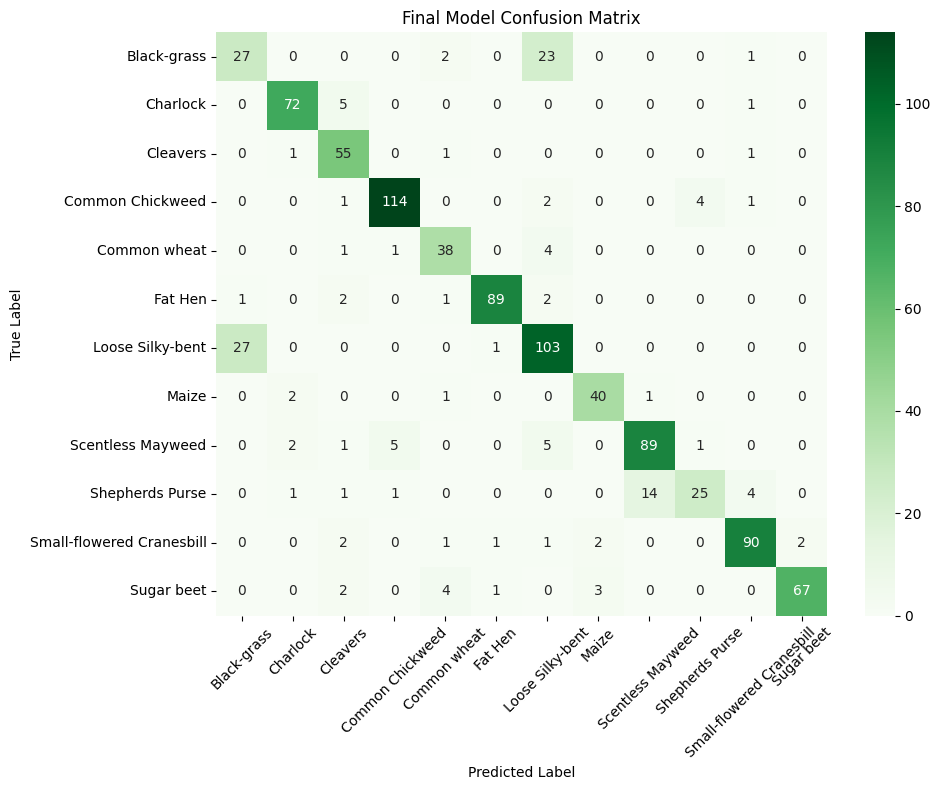

In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_final = confusion_matrix(y_true_final, y_pred_final)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

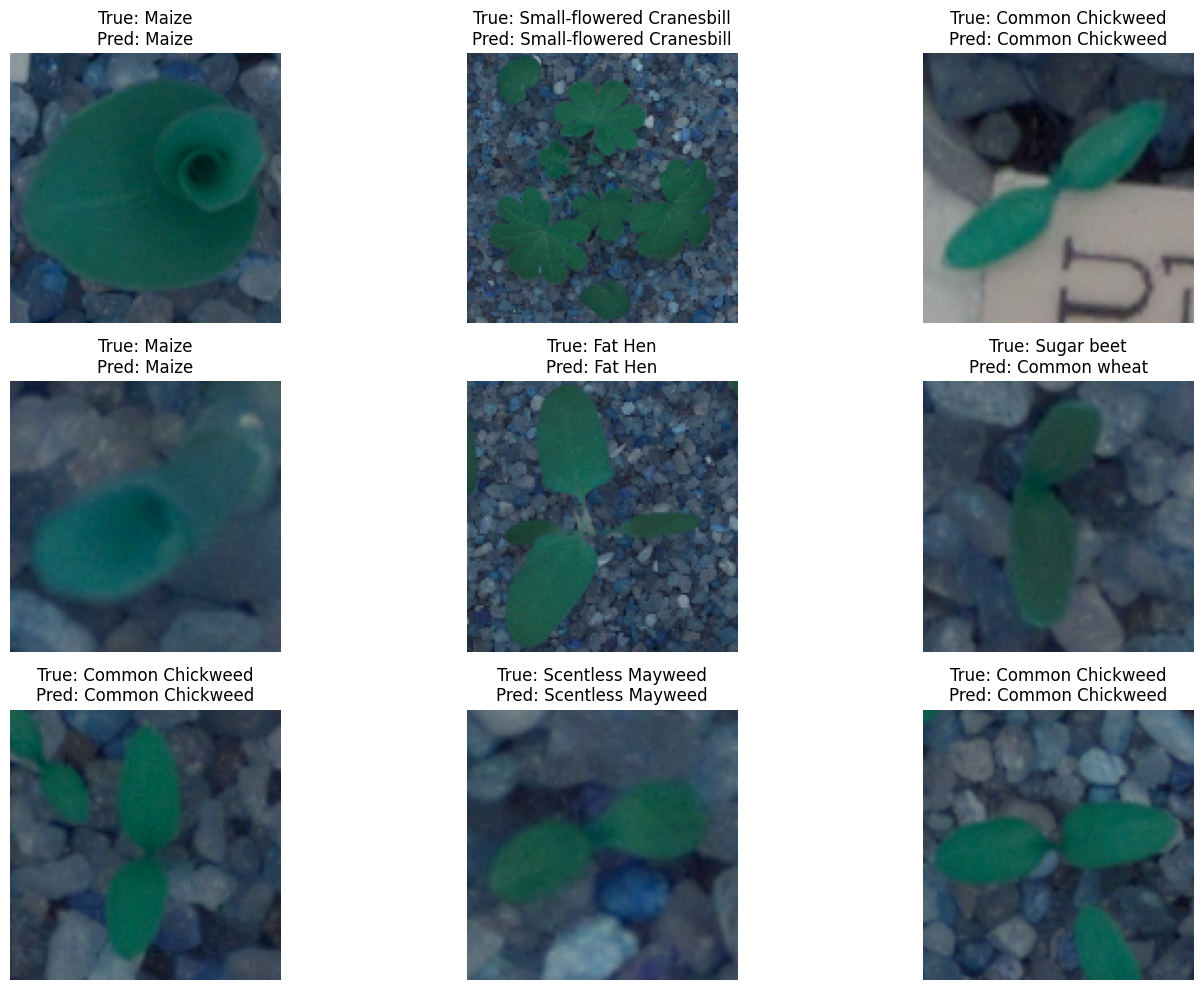

In [ ]:
# Sample images with predictions
plt.figure(figsize=(15, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i])

    true_label = le.inverse_transform([y_true_final[i]])[0]
    pred_label = le.inverse_transform([y_pred_final[i]])[0]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Number of wrongly classified images: 141


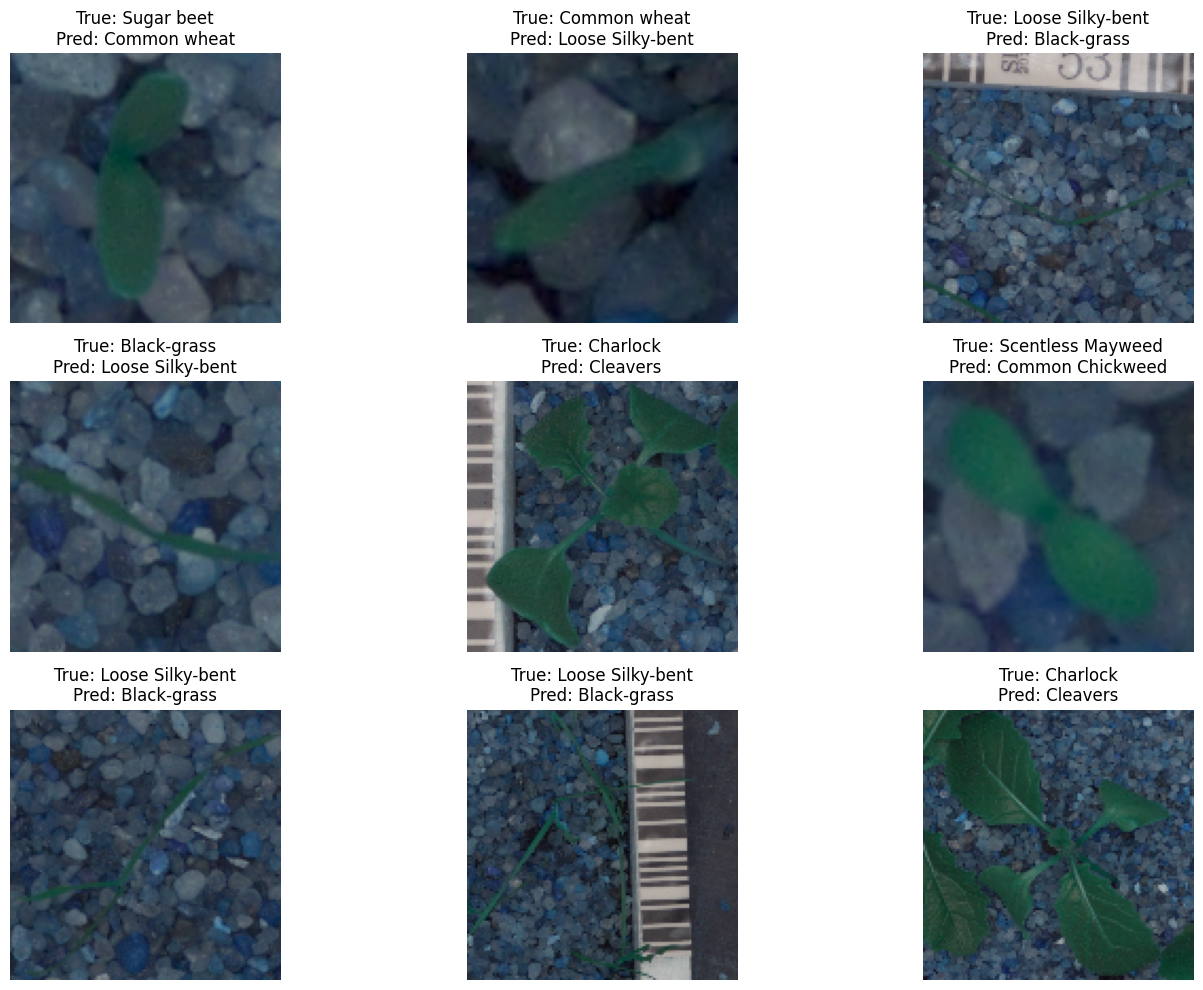

In [ ]:
# Wrongly matched images
wrong_idx = np.where(y_true_final != y_pred_final)[0]

print("Number of wrongly classified images:", len(wrong_idx))

plt.figure(figsize=(15, 10))

for i, idx in enumerate(wrong_idx[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[idx])

    true_label = le.inverse_transform([y_true_final[idx]])[0]
    pred_label = le.inverse_transform([y_pred_final[idx]])[0]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

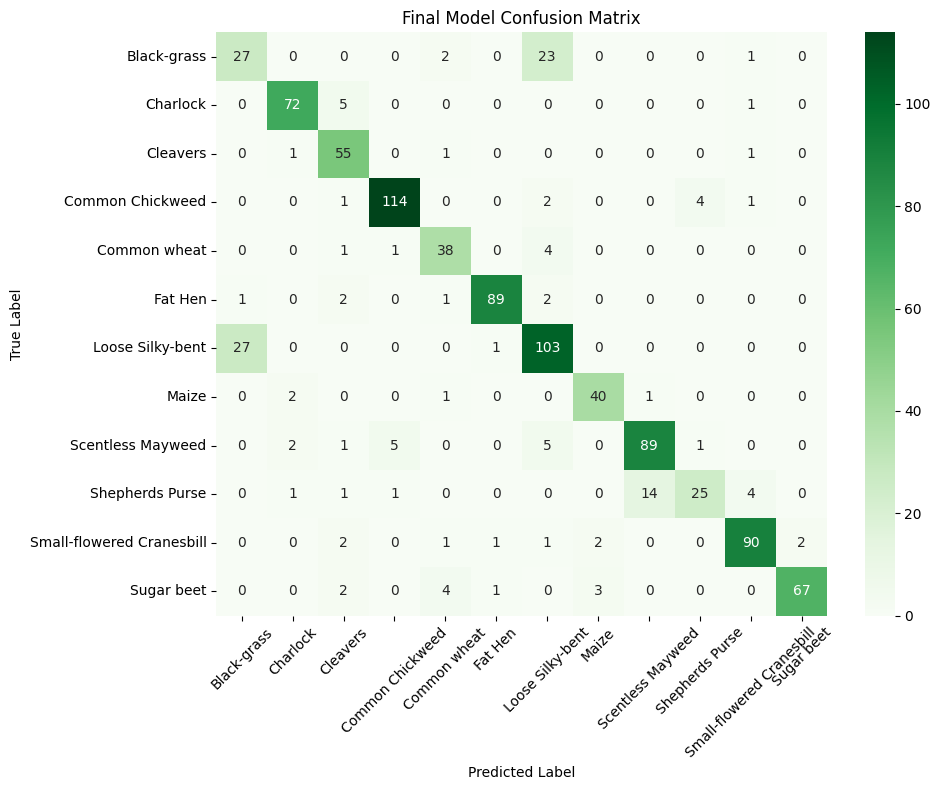

In [ ]:
#Save confusion matrix figure
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_final.png", dpi=300, bbox_inches="tight")
plt.show()

## Final Model Evaluation

The final CNN model was evaluated using classification metrics, confusion matrix, and visual inspection of predictions.

The classification report provides class-specific precision, recall, and F1-scores, while the confusion matrix highlights which plant species are more frequently confused. Sample predictions demonstrate the model’s practical classification performance, and the review of misclassified images helps identify visually similar classes that remain challenging.

Overall, the final model provides a strong proof of concept for automated plant seedling classification using deep learning.
The baseline model showed signs of overfitting, with training accuracy increasing faster than validation accuracy. The improved model reduced this gap through regularization (dropout, batch normalization, and data augmentation).

## Final Results

The baseline CNN achieved a test accuracy of approximately 77%, showing that convolutional neural networks can effectively classify plant seedlings from image data.

The improved CNN model, which incorporated batch normalization, dropout, data augmentation, and learning-rate scheduling, achieved a substantially stronger performance with test accuracy increasing to approximately 86%. This demonstrates that regularization and better training controls improved generalization and reduced overfitting.

The confusion matrix shows that the model performs strongly for several visually distinct plant species, while some misclassifications remain among species with similar visual structures, particularly among grass-like classes. This is consistent with the challenges of fine-grained image classification.

Overall, the final CNN model provides a strong proof of concept for automated plant seedling classification and demonstrates the practical value of deep learning in agricultural image analysis.

## Business Impact

This project demonstrates how deep learning can automate plant seedling identification in agricultural workflows.

Manual plant recognition is time-intensive and depends heavily on human expertise. By automating this task, the proposed CNN model can reduce manual labour, improve consistency, and accelerate crop monitoring processes.

Potential benefits include:
- Reduced labour and inspection time in agricultural operations
- Faster and more consistent crop and weed identification
- Improved support for crop monitoring and farm management decisions
- A foundation for scalable precision agriculture systems

This type of model could be extended into real-world applications such as mobile plant-identification tools, drone-assisted monitoring systems, or embedded AI solutions for agricultural automation.

## Conclusion

This project successfully developed a CNN-based deep learning solution for classifying plant seedlings across 12 species.

The workflow covered data preprocessing, exploratory analysis, model development, performance evaluation, and model improvement. The final model achieved strong classification performance and showed that CNNs are suitable for this type of agricultural image classification problem.

Beyond technical performance, the project highlights the real-world value of computer vision in agriculture. Automating plant classification can improve operational efficiency, reduce manual effort, and support more scalable monitoring systems.

Overall, this project demonstrates practical capability in deep learning, computer vision, and applied AI, and serves as a strong portfolio example of end-to-end model development for a real-world use case.

## Limitations and Future Work

Although the final CNN model achieved strong performance, some plant species with similar visual characteristics were more difficult to distinguish, leading to residual misclassifications.

Future work could improve performance further through:
- transfer learning with pre-trained architectures such as EfficientNet or ResNet
- hyperparameter tuning
- more advanced augmentation strategies
- larger and more diverse image datasets
- deployment as a real-time image classification application

These extensions would further strengthen model robustness and practical usability in agricultural environments.